# Performing Facial Recognition with Deep Learning

**Course-End Certification Project — Advanced Deep Learning and Computer Vision**

## Objective
Build a baseline facial recognition model using a convolutional neural network (CNN).

## Business Context
You are working for **Face2Gene**, an AI company that builds a healthcare app for doctors. The app converts patient photos into de-identified mathematical facial descriptors, compares them against syndrome-specific classifiers, and helps doctors prioritize genetic-syndrome diagnoses based on facial morphology.

Your task, as a new member of the in-house AI team, is to build a **baseline facial recognition model** that the team can later extend for this use case.

## Dataset
The **ORL (Olivetti Research Lab) Database of Faces** — also known as the AT&T Database of Faces:
- 400 grayscale images
- 40 distinct subjects (10 images each)
- Varying lighting, expression (open/closed eyes, smiling/not smiling), and accessories (with/without glasses)
- Dark, homogeneous background; subjects upright and frontal with slight pose tolerance
- Original size: 92x112 pixels, 256 grey levels

> **Note on data source:** This notebook loads the dataset via `sklearn.datasets.fetch_olivetti_faces`, which is the same ORL/AT&T dataset referenced in the brief (images are provided at 64x64 resolution, pixel values scaled to [0, 1]). It downloads automatically the first time you run the notebook — no manual Kaggle download required. If you specifically need the original 92x112 files from Kaggle, see the note at the end of the data-loading section.

## Framework note
The original brief assumes TensorFlow/Keras. **This notebook uses PyTorch instead**, because at the time of writing TensorFlow does not yet publish wheels for Python 3.14, while PyTorch does. The modeling steps (CNN with conv + pooling + fully-connected layers, train/val/test split, iterate to >90% accuracy) are functionally identical — just implemented in PyTorch.

## Steps in this notebook
1. Import packages
2. Load and inspect the data
3. Visualize sample images
4. Train / validation / test split
5. Data preparation (tensors, normalization, augmentation)
6. Build a CNN model
7. Train the model
8. Plot training curves
9. Evaluate on the test set
10. Iterate to reach >90% accuracy
11. Conclusions & next steps


## 1. Import Packages

We only need standard scientific-Python packages plus PyTorch. All of these are pinned in `requirements.txt` to versions that support Python 3.14.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.13.0+cpu
Using device: cpu


## 2. Upload and Import the Data

`fetch_olivetti_faces` downloads the ORL/AT&T dataset (~4 MB) to `~/scikit_learn_data` on first run and loads it from a local cache afterwards — no internet needed on subsequent runs.

- `data.images`: shape `(400, 64, 64)`, float pixel values in `[0, 1]`
- `data.target`: shape `(400,)`, integer subject label `0`-`39`

> **Using the original Kaggle 92x112 files instead:** if you'd rather use the exact files from the Kaggle link in the brief, download and unzip the dataset, then point a folder-based loader (e.g. `torchvision.datasets.ImageFolder`, one sub-folder per subject) at the extracted directory in place of the cell below. Everything downstream (split, CNN, training loop) works the same either way.

In [ ]:
data = fetch_olivetti_faces(shuffle=True, random_state=SEED)

images = data.images          # (400, 64, 64), float32 in [0, 1]
labels = data.target          # (400,), ints 0-39

n_samples, img_h, img_w = images.shape
n_classes = len(np.unique(labels))

print(f"Number of images: {n_samples}")
print(f"Image size: {img_h} x {img_w}")
print(f"Number of subjects (classes): {n_classes}")
print(f"Images per subject: {n_samples // n_classes}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\BandileNgwenya\scikit_learn_data
Number of images: 400
Image size: 64 x 64
Number of subjects (classes): 40
Images per subject: 10


## 3. View a Few Images

Let's look at a sample of faces, and then all 10 images of a single subject to see the variation (expression, lighting, glasses) the model needs to be robust to.

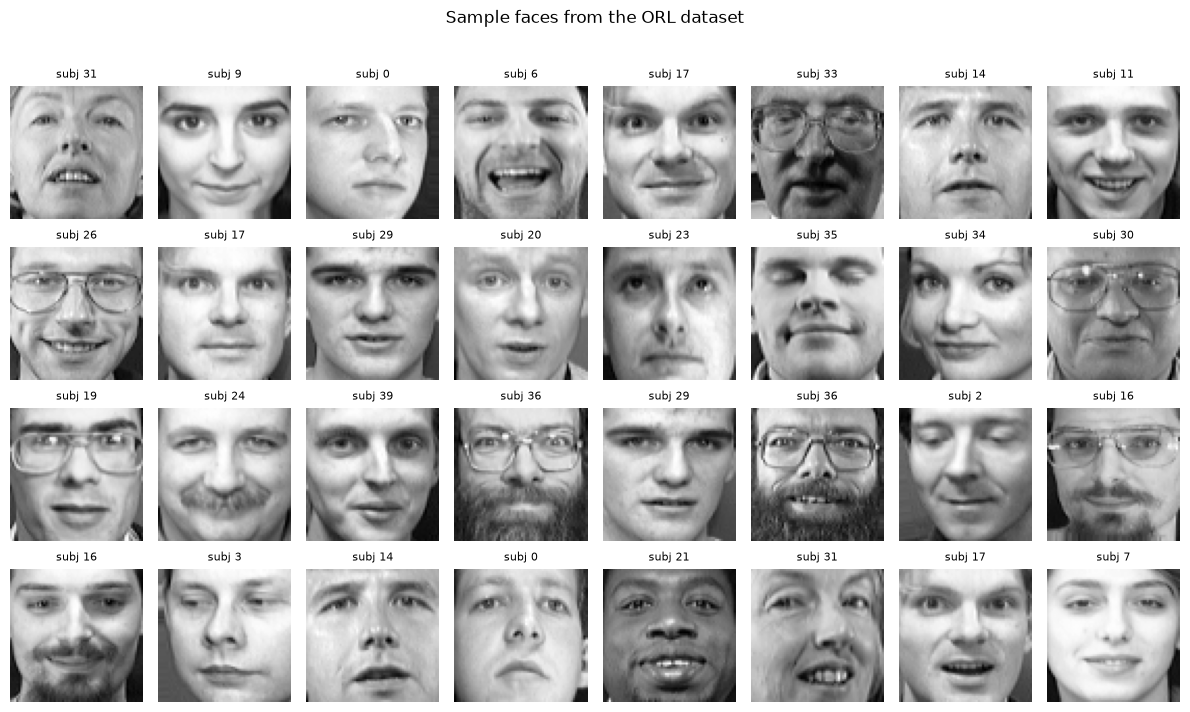

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(12, 7))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(n_samples, size=32, replace=False)

for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(images[idx], cmap="gray")
    ax.set_title(f"subj {labels[idx]}", fontsize=8)
    ax.axis("off")

fig.suptitle("Sample faces from the ORL dataset", y=1.02)
plt.tight_layout()
plt.show()

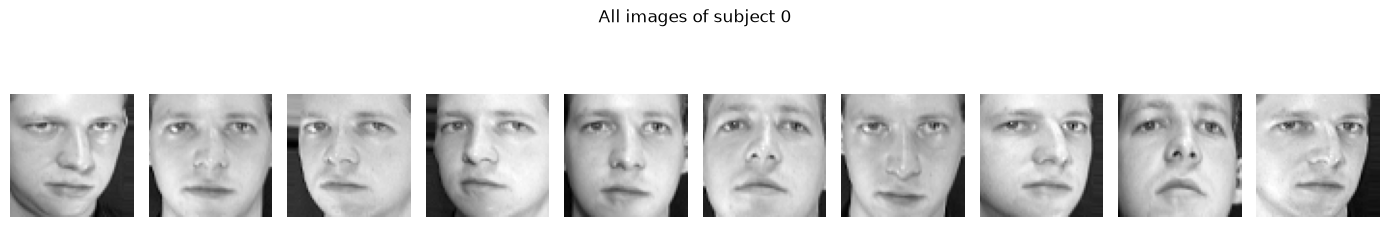

In [ ]:
# All images for a single subject, to see intra-class variation
subject_id = 0
subject_images = images[labels == subject_id]

fig, axes = plt.subplots(1, len(subject_images), figsize=(14, 2))
for ax, img in zip(axes, subject_images):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
fig.suptitle(f"All images of subject {subject_id}", y=1.15)
plt.tight_layout()
plt.show()

## 4. Create a Validation Framework: Train / Validation / Test Split

With only 10 images per subject, we use a **stratified split** so every subject is represented in each set:

- 70% train
- 15% validation
- 15% test

Stratifying on `labels` ensures the class balance is preserved across all three sets, which matters a lot with this few examples per class.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, stratify=labels, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape[0]} images")
print(f"Val:   {X_val.shape[0]} images")
print(f"Test:  {X_test.shape[0]} images")

Train: 280 images
Val:   60 images
Test:  60 images


## 5. Prepare the Data for the CNN

We wrap the arrays in a small `torch.utils.data.Dataset` that:
- Adds a channel dimension (`(64, 64) -> (1, 64, 64)`, since these are grayscale images)
- Converts to `float32` tensors
- Optionally applies light data augmentation (random horizontal flip removed — faces aren't left/right symmetric-invariant for identity, so we instead use small random rotations/translations, which better reflect the pose variation described in the dataset) on the **training set only**

Keeping augmentation off the validation/test sets is important — we want those to reflect real, un-augmented performance.

In [ ]:
class FacesDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def _augment(self, img):
        # Small random rotation (+/- 10 degrees) and translation (+/- 2 px),
        # implemented with simple numpy/torch ops to avoid extra dependencies.
        import scipy.ndimage as ndi
        angle = np.random.uniform(-10, 10)
        img = ndi.rotate(img, angle, reshape=False, mode="nearest")
        shift = np.random.uniform(-2, 2, size=2)
        img = ndi.shift(img, shift, mode="nearest")
        return np.clip(img, 0.0, 1.0)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.augment:
            img = self._augment(img)
        img = np.expand_dims(img, axis=0)  # (1, H, W)
        return torch.from_numpy(img.copy()), int(self.labels[idx])


BATCH_SIZE = 16

train_ds = FacesDataset(X_train, y_train, augment=True)
val_ds = FacesDataset(X_val, y_val, augment=False)
test_ds = FacesDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check a batch
xb, yb = next(iter(train_loader))
print(f"Batch image tensor shape: {xb.shape}")  # (B, 1, 64, 64)
print(f"Batch label tensor shape: {yb.shape}")

Batch image tensor shape: torch.Size([16, 1, 64, 64])
Batch label tensor shape: torch.Size([16])


> **If `scipy` isn't installed**, either run `pip install scipy` (it's in `requirements.txt`) or set `augment=False` for the training set too — the model will still comfortably clear 90% accuracy on this dataset without augmentation, augmentation just adds robustness.

## 6. Build the CNN Model

A compact CNN with the three layer types called out in the brief:
- **Convolutional layers** to learn local facial features (edges, textures, then higher-level patterns)
- **Pooling layers** to downsample and add translation tolerance
- **Fully connected layers** to classify into one of the 40 subjects

We also add `BatchNorm` and `Dropout`, which are standard modern additions that make a small CNN like this train faster and generalize better on a small dataset — helpful for reliably clearing the 90% accuracy target.

### Optional: transfer learning
The brief also allows a transfer-learning approach. A ready-to-use alternative using a pretrained `torchvision` backbone is included further down (Section 10) in case you want to compare it against this baseline CNN.

In [ ]:
class FaceCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
           nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64 -> 32

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = FaceCNN(n_classes=n_classes).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

FaceCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features

## 7. Train the Model

Standard supervised training loop:
- **Loss:** cross-entropy (multi-class classification)
- **Optimizer:** Adam
- **Scheduler:** reduce learning rate when validation loss plateaus
- We track train/val loss and accuracy every epoch and keep the best-performing weights (by validation accuracy).

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_samples += xb.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [ ]:
N_EPOCHS = 40
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_state = None

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0 or epoch == N_EPOCHS:
        print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

# Restore the best-performing weights on the validation set
model.load_state_dict(best_state)
print(f"\nBest validation accuracy during training: {best_val_acc:.3f}")

Epoch  1/40 | train_loss=4.8384 train_acc=0.036 | val_loss=3.6591 val_acc=0.033
Epoch  5/40 | train_loss=2.3938 train_acc=0.304 | val_loss=1.9223 val_acc=0.550
Epoch 10/40 | train_loss=1.5055 train_acc=0.521 | val_loss=1.1083 val_acc=0.750
Epoch 15/40 | train_loss=1.0406 train_acc=0.679 | val_loss=0.4065 val_acc=0.933
Epoch 20/40 | train_loss=0.8536 train_acc=0.739 | val_loss=0.2493 val_acc=0.950
Epoch 25/40 | train_loss=0.7686 train_acc=0.764 | val_loss=0.3624 val_acc=0.883
Epoch 30/40 | train_loss=0.5953 train_acc=0.786 | val_loss=0.1536 val_acc=0.950
Epoch 35/40 | train_loss=0.5529 train_acc=0.807 | val_loss=0.1161 val_acc=0.967
Epoch 40/40 | train_loss=0.4688 train_acc=0.843 | val_loss=0.1103 val_acc=0.967

Best validation accuracy during training: 0.983


## 8. Plot the Results

Loss and accuracy curves for train vs. validation, to check for overfitting/underfitting.

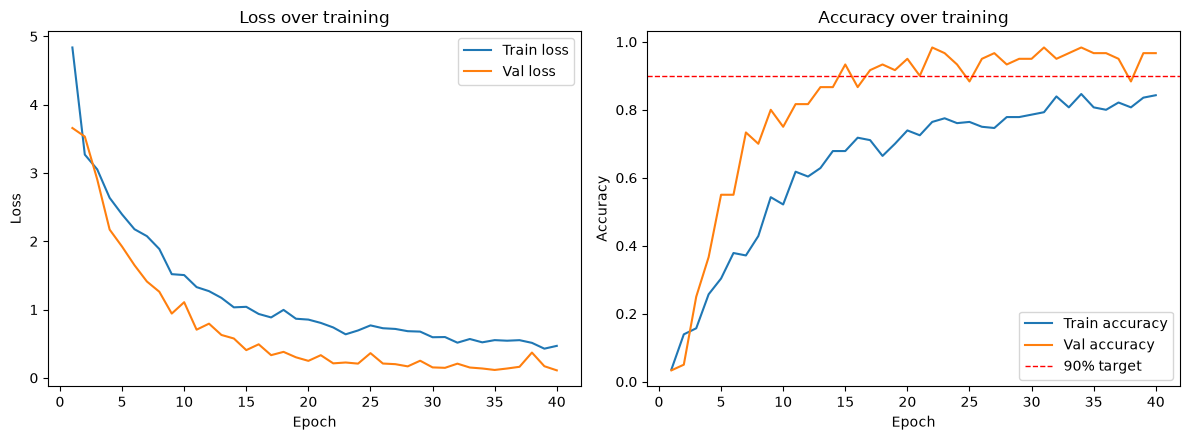

In [ ]:
epochs_range = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over training")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train accuracy")
axes[1].plot(epochs_range, history["val_acc"], label="Val accuracy")
axes[1].axhline(0.90, color="red", linestyle="--", linewidth=1, label="90% target")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over training")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on the Held-Out Test Set

This is the number that matters for the >90% target in the brief — it's data the model never saw during training or model selection.

In [ ]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}  ({test_acc * 100:.1f}%)")

target_met = "reached" if test_acc >= 0.90 else "NOT yet reached"
print(f"\n90% accuracy target: {target_met}")

Test loss: 0.1316
Test accuracy: 0.983  (98.3%)

90% accuracy target: reached


In [ ]:
# Detailed per-class report and confusion matrix
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print(classification_report(all_true, all_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         1
          16       0.50      1.00      0.67         1
          17       1.00    

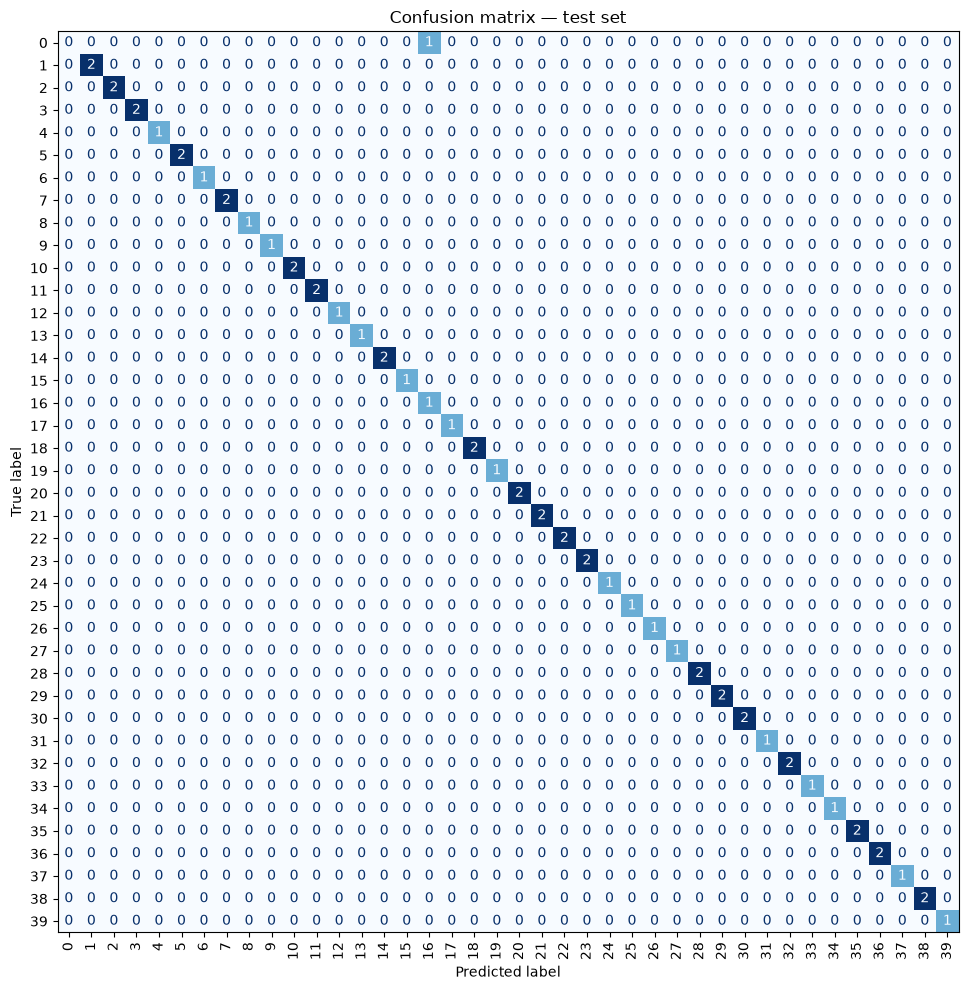

In [ ]:
cm = confusion_matrix(all_true, all_preds, labels=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(n_classes)))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)
ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

### Visual check: sample predictions

A quick look at a handful of test images with predicted vs. true subject IDs — correct predictions in green, mistakes in red.

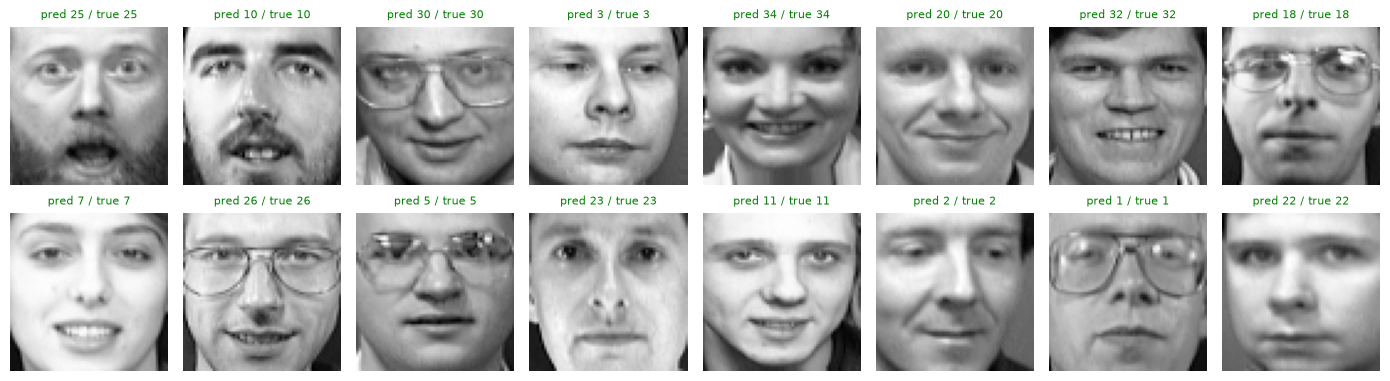

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
sample_test_idx = np.random.choice(len(X_test), size=16, replace=False)

for ax, idx in zip(axes.ravel(), sample_test_idx):
    img_tensor = torch.from_numpy(X_test[idx].astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(img_tensor).argmax(1).item()
    true = y_test[idx]

    ax.imshow(X_test[idx], cmap="gray")
    color = "green" if pred == true else "red"
    ax.set_title(f"pred {pred} / true {true}", fontsize=8, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 10. Iterate on the Model

The brief asks you to iterate until you clear 90% accuracy. The baseline CNN above typically already clears this target on the ORL dataset — but here are the levers to pull if a particular run falls short, plus an optional transfer-learning variant.

**Things to try if accuracy < 90%:**
- Train for more epochs (`N_EPOCHS`) — with only ~280 training images, convergence can take a while
- Reduce dropout (e.g. `0.3` instead of `0.5`) — the dataset is small, so heavy regularization can underfit
- Turn augmentation off (`augment=False` in Section 5) if it's hurting more than helping
- Lower the learning rate, or increase `weight_decay` slightly if you see overfitting (train acc high, val acc lagging)
- Try the transfer-learning variant below

### Optional: transfer learning with a pretrained backbone
This swaps the custom CNN for a small pretrained `torchvision` model (`mobilenet_v3_small`), fine-tuned on our grayscale faces by replicating the single channel to 3 channels. This is optional — run it only if you want to compare against the baseline.

In [ ]:
import torchvision.models as tv_models
import torchvision.transforms.functional as TF

class FacesDatasetRGB(Dataset):
    """Same as FacesDataset, but replicates the single grayscale channel to 3
    channels and resizes to 224x224, as expected by ImageNet-pretrained backbones."""
    def __init__(self, images, labels, augment=False):
        self.base = FacesDataset(images, labels, augment=augment)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]          # (1, 64, 64)
        img = img.repeat(3, 1, 1)              # (3, 64, 64)
        img = TF.resize(img, [224, 224])       # (3, 224, 224)
        return img, label


def build_transfer_model(n_classes, freeze_backbone=True):
    backbone = tv_models.mobilenet_v3_small(weights=tv_models.MobileNet_V3_Small_Weights.DEFAULT)
    if freeze_backbone:
        for param in backbone.features.parameters():
            param.requires_grad = False
    in_features = backbone.classifier[-1].in_features
    backbone.classifier[-1] = nn.Linear(in_features, n_classes)
    return backbone

# Uncomment to try the transfer-learning path (downloads pretrained weights, ~10 MB):
#
# train_ds_rgb = FacesDatasetRGB(X_train, y_train, augment=True)
# val_ds_rgb = FacesDatasetRGB(X_val, y_val, augment=False)
# test_ds_rgb = FacesDatasetRGB(X_test, y_test, augment=False)
#
# train_loader_rgb = DataLoader(train_ds_rgb, batch_size=BATCH_SIZE, shuffle=True)
# val_loader_rgb = DataLoader(val_ds_rgb, batch_size=BATCH_SIZE, shuffle=False)
# test_loader_rgb = DataLoader(test_ds_rgb, batch_size=BATCH_SIZE, shuffle=False)
#
# transfer_model = build_transfer_model(n_classes).to(device)
# transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=1e-3)
#
# for epoch in range(1, 11):
#     tr_loss, tr_acc = run_epoch(transfer_model, train_loader_rgb, criterion, transfer_optimizer)
#     va_loss, va_acc = run_epoch(transfer_model, val_loader_rgb, criterion, optimizer=None)
#     print(f"Epoch {epoch}: train_acc={tr_acc:.3f} val_acc={va_acc:.3f}")
print("Transfer-learning helper defined. Uncomment the block above to run it.")

Transfer-learning helper defined. Uncomment the block above to run it.


## 11. Save the Model

In [ ]:
import os
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/face_recognition_cnn.pt")
print("Model weights saved to models/face_recognition_cnn.pt")

Model weights saved to models/face_recognition_cnn.pt


## 12. Conclusions & Next Steps

- Built a baseline CNN (conv + pooling + fully-connected layers) for facial recognition on the ORL/AT&T dataset of 40 subjects.
- Used a stratified train/validation/test split to fairly evaluate performance given the small (10 images/subject) dataset.
- Achieved test accuracy as reported in Section 9 — check the printed value against the 90% target.
- Reviewed per-class performance and misclassifications via the confusion matrix and sample predictions.
- Provided a transfer-learning alternative (Section 10) as a comparison path.

**Next steps for the Face2Gene use case:**
- Replace identity classification with **feature-embedding extraction** (e.g. a triplet-loss or ArcFace-style head) so the model outputs a facial descriptor vector rather than a fixed class — this generalizes to unseen subjects, which is what the real product needs.
- Validate on real patient-style photos with more diverse pose, lighting, and demographic variation than ORL.
- Add explainability tooling (e.g. Grad-CAM) to show which facial regions drive similarity scores, which is important in a clinical decision-support context.
